Connected to database for visualization


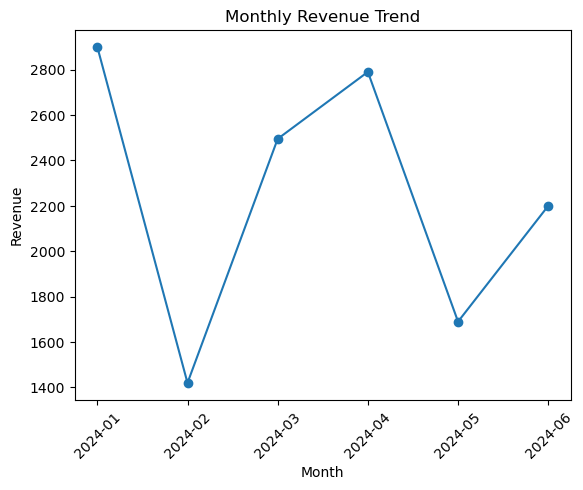

<Figure size 640x480 with 0 Axes>

In [7]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# CONNECT TO DATABASE
conn = sqlite3.connect("retail_store.db")

print("Connected to database for visualization")
print("="*50)


# 1. MONTHLY REVENUE TREND

df_month = pd.read_sql_query("""
    SELECT
        SUBSTR(o.order_date, 1, 7) AS month,
        SUM(p.price * o.quantity) AS revenue
    FROM orders o
    JOIN products p ON o.product_id = p.product_id
    GROUP BY month
    ORDER BY month
""", conn)

plt.figure()
plt.plot(df_month["month"], df_month["revenue"], marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# SAVE IMAGE
plt.savefig("Monthly_revenue_trend.png")


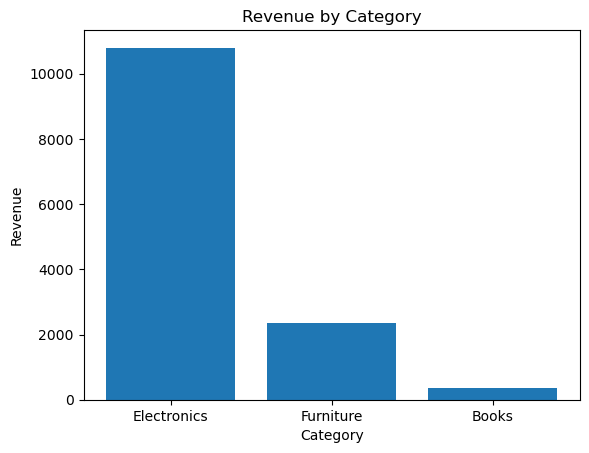

<Figure size 640x480 with 0 Axes>

In [8]:
# 2. REVENUE BY CATEGORY

df_cat = pd.read_sql_query("""
    SELECT
        p.category,
        SUM(p.price * o.quantity) AS revenue
    FROM orders o
    JOIN products p ON o.product_id = p.product_id
    GROUP BY p.category
    ORDER BY revenue DESC
""", conn)

plt.figure()
plt.bar(df_cat["category"], df_cat["revenue"])
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

# SAVE IMAGE
plt.savefig("Revenue_by_category.png")

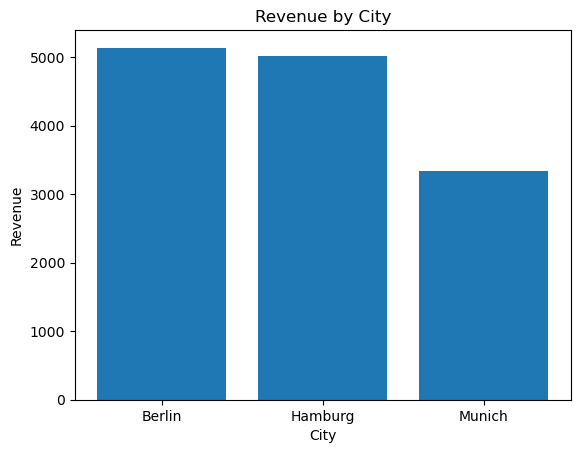


All charts generated!


<Figure size 640x480 with 0 Axes>

In [9]:
# 3. REVENUE BY CITY

df_city = pd.read_sql_query("""
    SELECT
        c.city,
        SUM(p.price * o.quantity) AS revenue
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN products p  ON o.product_id  = p.product_id
    GROUP BY c.city
    ORDER BY revenue DESC
""", conn)

plt.figure()
plt.bar(df_city["city"], df_city["revenue"])
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()


# SAVE IMAGE
plt.savefig("Revenue_by_city.png")


# CLOSE CONNECTION
conn.close()
print("\nAll charts generated!")
